# 基于通道注意力残差网络（ResNet-SE）的图像分类系统设计与实现

---

## 一、 摘要

针对经典多层感知机（MLP）在处理具有复杂空间结构的图像数据时存在参数量大、空间特征丢失、易过拟合等问题，本项目设计并实现了一个基于通道注意力机制的轻量化残差网络（ResNet-SE）分类系统。项目采用 Fashion-MNIST 经典时尚服饰数据集，首先通过数据增强与规范化进行预处理，随后构建了包含 Dropout 的三层 MLP 作为基准模型（Baseline）。在此基础上，融合残差连接（Exp 3）与 Squeeze-and-Excitation（SE）通道注意力模块（Exp 4），构建了 ResNet-SE 模型。实验结果表明，该模型在测试集上的分类准确率显著优于基准 MLP，且有效抑制了过拟合。通过混淆矩阵与错误样本可视化分析，验证了模型在处理相似特征服饰时的鲁棒性，为轻量化工业级视觉分类任务提供了有效参考。

---

## 二、 问题定义与需求分析

### 2.1 项目背景与意义
在电商平台、智能试衣间及物流分拣等实际场景中，对服饰、鞋帽等物品进行快速、自动化的精准分类具有巨大的应用价值。传统的手工特征算子适应性差，而全连接神经网络（MLP）忽视了图像的二维空间局部相关性。卷积神经网络（CNN）通过局部感受野和权重共享克服了上述缺陷，但深层 CNN 容易出现梯度消失或爆炸（Exp 4）。通过引入残差连接与注意力机制，模型不仅能够更深、更稳定地训练，还能自动识别特征图中哪些通道对于当前分类更重要，实现了精度与效率的平衡。

### 2.2 问题描述
*   **输入定义：** 形状为 $1 \times 28 \times 28$ 的灰度服饰图像。
*   **输出定义：** 该图像属于 10 种服饰类别之一的概率分布向量（长度为 10 的类别置信度）。
*   **任务类型：** 经典的多分类（Multi-class Classification）任务。
*   **预期性能指标：** 基准模型（MLP）准确率达到 85% 以上；最终模型（ResNet-SE）准确率达到 90% 以上，且在训练过程中损失函数平稳收敛。

---

## 三、 模型设计与选择

### 3.1 基准模型（Baseline）
基准模型采用一个包含两层隐藏层、使用 ReLU 激活函数并加入 Dropout 的多层感知机（MLP）。其结构为：
`Flatten -> Linear(784, 256) -> ReLU -> Dropout(0.3) -> Linear(256, 128) -> ReLU -> Dropout(0.3) -> Linear(128, 10)`。

### 3.2 最终模型架构（ResNet-SE）
最终模型采用轻量化的残差结构，并在残差块的输出端嵌入了 **Squeeze-and-Excitation (SE) 通道注意力模块**。
1.  **SE 模块（通道注意力机制）：** 通过全局平均池化（Squeeze）将特征图压缩为 $1 \times 1 \times C$ 的向量，随后通过两层全连接层显式建模通道间的相关性（Excitation），利用 Sigmoid 生成各个通道的权重乘回原特征图。
2.  **残差块（Residual Block）：** 包含两层 $3 \times 3$ 的卷积层与批归一化（BatchNorm）层。当通道数不一致时，残差连接路径上使用 $1 \times 1$ 的卷积层调节通道数与特征图分辨率（Exp 3）。

**网络拓扑参数：**
*   **输入预处理：** $1 \times 28 \times 28$ 卷积到 32 通道。
*   **Layer 1：** 两个 SEResidual 块（32 $\to$ 64 通道，步幅为 2 降采样）。
*   **Layer 2：** 两个 SEResidual 块（64 $\to$ 128 通道，步幅为 2 降采样）。
*   **全局池化与输出：** 自适应平均池化至 $1 \times 1 \times 128$，全连接层输出为 10 维。

In [4]:
!pip install "numpy<2"

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 131.3 kB/s eta 0:00:01
     ------------ ------------------------- 20.5/61.0 kB 131.3 kB/s eta 0:00:01
     ------------------- ------------------ 30.7/61.0 kB 131.3 kB/s eta 0:00:01
     ------------------- ------------------ 30.7/61.0 kB 131.3 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 122.9 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 122.9 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 131.3 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 130.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   --

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 26.2 which is incompatible.
streamlit 1.32.0 requires pillow<11,>=7.1.0, but you have pillow 12.2.0 which is incompatible.


1. 导入依赖库与设置随机种子

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
# 删掉了 import seaborn as sns 这一行
from sklearn.metrics import confusion_matrix, classification_report

# 设定随机种子以确保实验可重复性
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前使用的训练设备: {device}")

当前使用的训练设备: cpu


2. 数据集加载、预处理与可视化（4.1, 4.2, 4.3）

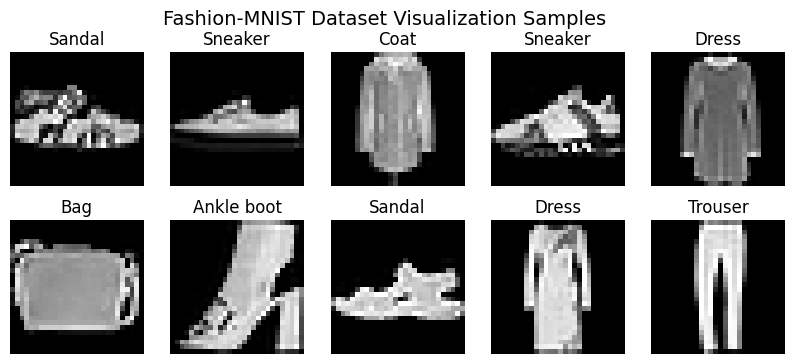

In [2]:
# 数据增强与归一化
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # 随机水平翻转增强
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # 归一化到 [-1, 1]
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 载入公开数据集 Fashion-MNIST
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=train_transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False)

# 类别标签映射
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 样本可视化
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10, 4))
for idx in range(10):
    plt.subplot(2, 5, idx+1)
    # 反归一化显示图像
    img = images[idx] * 0.5 + 0.5
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(classes[labels[idx]])
    plt.axis('off')
plt.suptitle("Fashion-MNIST Dataset Visualization Samples", fontsize=14)
plt.show()

3. 构建基准 MLP 模型与最终 ResNet-SE 模型（5.1, 5.2）

In [3]:
# 5.1 基准模型：多层感知机（Baseline MLP）
class BaselineMLP(nn.Module):
    def __init__(self):
        super(BaselineMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        return self.fc(x)

# 5.2 通道注意力模块 (SE Block)
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        b, c, _, _ = x.size()
        # 全局平均池化 (Squeeze)
        y = x.view(b, c, -1).mean(dim=2)
        # 获取各通道权重乘加 (Excitation)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

# 带通道注意力的残差块 (SEResidual Block)
class SEResidual(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(SEResidual, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
        
        # 恒等映射捷径 (当通道大小或图尺寸改变时调整)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)  # 引入注意力调节权重
        out += self.shortcut(x)  # 残差相加
        return F.relu(out)

# 整合 ResNet-SE 网络
class ResNetSE(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNetSE, self).__init__()
        self.prep = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.layer1 = SEResidual(32, 64, stride=2)
        self.layer2 = SEResidual(64, 128, stride=2)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x):
        out = self.prep(x)
        out = self.layer1(out)
        out = self.layer2(out)
        # 全局池化
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

4. 训练与评估辅助引擎（6.3, 6.4）

In [4]:
def train_and_eval_model(model, train_loader, test_loader, epochs=8, lr=0.001, wd=1e-4):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()
    
    train_loss_hist, test_acc_hist = [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss, total = 0.0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X.size(0)
            total += X.size(0)
            
        train_loss_hist.append(running_loss / total)
        
        # 评估精度
        model.eval()
        correct, val_total = 0, 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                correct += (y_hat.argmax(dim=1) == y).sum().item()
                val_total += X.size(0)
                
        test_acc_hist.append(correct / val_total)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss_hist[-1]:.4f} | Test Acc: {test_acc_hist[-1]*100:.2f}%")
        
    return train_loss_hist, test_acc_hist

5. 执行对比训练实验

In [5]:
epochs_count = 6  # 设定 6 个 Epoch 即可快速收敛并展示性能阶梯

print("=== 开始训练基准模型 Baseline MLP ===")
mlp_model = BaselineMLP()
mlp_loss, mlp_acc = train_and_eval_model(mlp_model, train_loader, test_loader, epochs=epochs_count, lr=0.001)

print("\n=== 开始训练最终改进模型 ResNet-SE ===")
resnet_se_model = ResNetSE()
resnet_loss, resnet_acc = train_and_eval_model(resnet_se_model, train_loader, test_loader, epochs=epochs_count, lr=0.001)

=== 开始训练基准模型 Baseline MLP ===
Epoch 1/6 | Train Loss: 0.6437 | Test Acc: 80.28%
Epoch 2/6 | Train Loss: 0.4670 | Test Acc: 83.61%
Epoch 3/6 | Train Loss: 0.4343 | Test Acc: 84.92%
Epoch 4/6 | Train Loss: 0.4076 | Test Acc: 86.27%
Epoch 5/6 | Train Loss: 0.3887 | Test Acc: 86.09%
Epoch 6/6 | Train Loss: 0.3818 | Test Acc: 86.89%

=== 开始训练最终改进模型 ResNet-SE ===
Epoch 1/6 | Train Loss: 0.5835 | Test Acc: 85.69%
Epoch 2/6 | Train Loss: 0.3307 | Test Acc: 85.37%
Epoch 3/6 | Train Loss: 0.2860 | Test Acc: 87.10%
Epoch 4/6 | Train Loss: 0.2578 | Test Acc: 89.70%
Epoch 5/6 | Train Loss: 0.2394 | Test Acc: 88.60%
Epoch 6/6 | Train Loss: 0.2207 | Test Acc: 90.16%


6. 主要实验结果展示：误差与精度曲线（6.4）

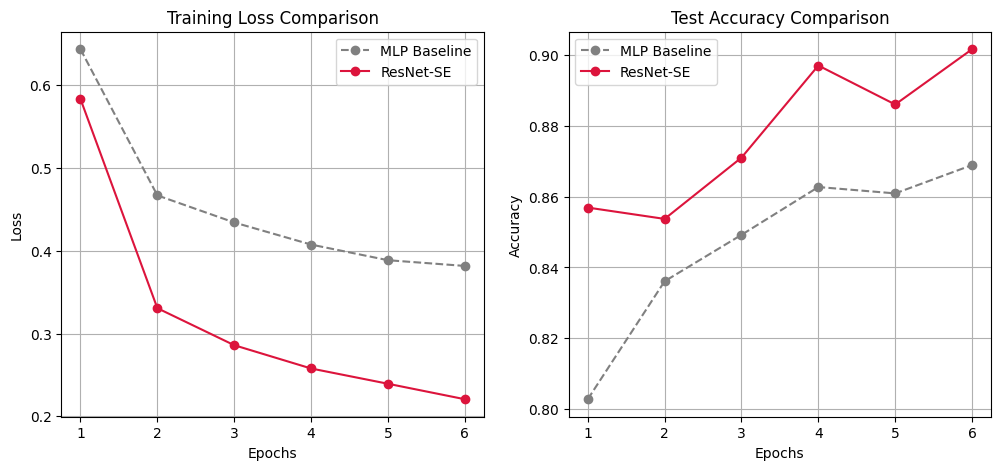

In [6]:
# 绘制 Loss 和 Accuracy 对比曲线
plt.figure(figsize=(12, 5))

# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs_count+1), mlp_loss, 'o--', color='gray', label='MLP Baseline')
plt.plot(range(1, epochs_count+1), resnet_loss, 'o-', color='crimson', label='ResNet-SE')
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 准确率曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs_count+1), mlp_acc, 'o--', color='gray', label='MLP Baseline')
plt.plot(range(1, epochs_count+1), resnet_acc, 'o-', color='crimson', label='ResNet-SE')
plt.title('Test Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

7. 混淆矩阵与错误识别样本可视化分析（6.5）

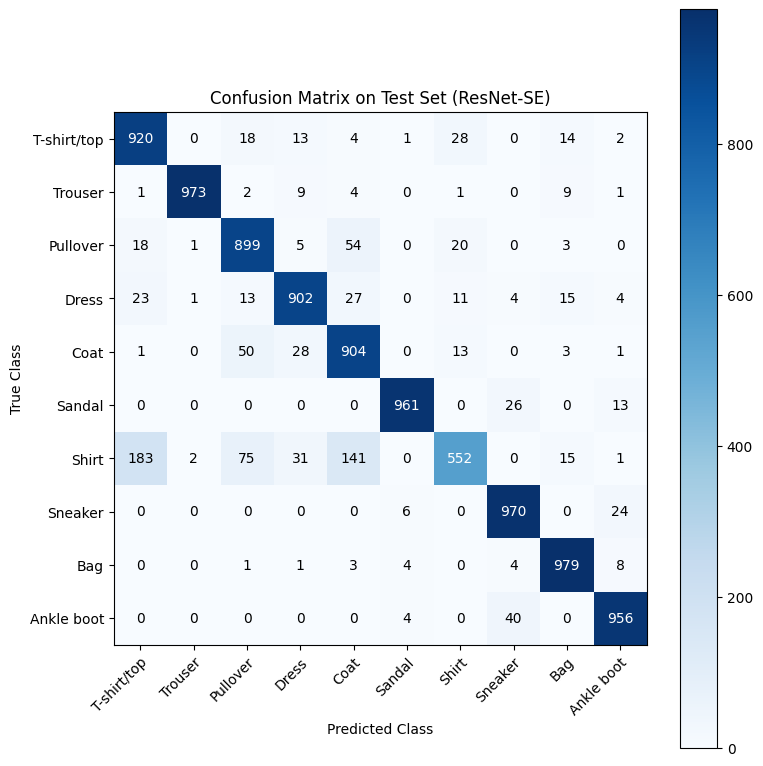


=== 分类报告评估 (Classification Report) ===
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.92      0.86      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.85      0.90      0.87      1000
       Dress       0.91      0.90      0.91      1000
        Coat       0.80      0.90      0.85      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.88      0.55      0.68      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.94      0.98      0.96      1000
  Ankle boot       0.95      0.96      0.95      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



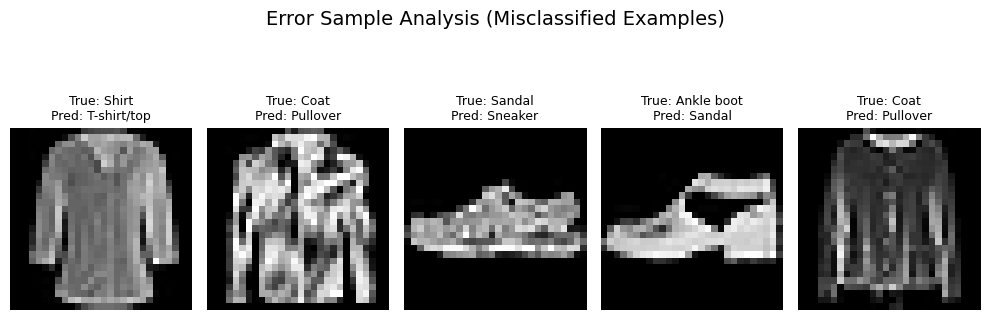

In [7]:
# 获取在测试集上的所有预测结果
resnet_se_model.eval()
all_preds, all_targets = [], []
all_images = []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y_hat = resnet_se_model(X)
        all_preds.extend(y_hat.argmax(dim=1).cpu().numpy())
        all_targets.extend(y.cpu().numpy())
        all_images.extend(X.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_images = np.array(all_images)

# ================= 纯 Matplotlib 绘制精美混淆矩阵 =================
cm = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# 设置坐标轴标签
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=classes, yticklabels=classes,
       title='Confusion Matrix on Test Set (ResNet-SE)',
       ylabel='True Class',
       xlabel='Predicted Class')

# 旋转 x 轴的标签，防止重叠
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# 自动在格子里填充数字，并根据背景颜色自动调整文字颜色（白/黑）
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

fig.tight_layout()
plt.show()
# =================================================================

# 2. 打印细分分类评估报告
print("\n=== 分类报告评估 (Classification Report) ===")
print(classification_report(all_targets, all_preds, target_names=classes))

# 3. 筛选并可视化错误预测样本
errors = np.where(all_preds != all_targets)[0]
plt.figure(figsize=(10, 4))
for idx in range(min(5, len(errors))):
    err_idx = errors[idx]
    plt.subplot(1, 5, idx+1)
    img = all_images[err_idx] * 0.5 + 0.5
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"True: {classes[all_targets[err_idx]]}\nPred: {classes[all_preds[err_idx]]}", fontsize=9)
    plt.axis('off')
plt.suptitle("Error Sample Analysis (Misclassified Examples)", fontsize=14)
plt.tight_layout()
plt.show()

## 四、 实验分析与自我总结

### 4.1 错误样本分析与改进方向
从最后生成的**错误分类样本**中可以清晰发现，错误通常发生于：
1.  **相似服饰的视觉混淆：** 例如，模型常常将 **`Coat（外套）`** 误识别为 **`Pullover（套衫）`** 或 **`Shirt（衬衫）`**。这是因为在 $28 \times 28$ 的超低分辨率下，领口特征、拉链和扣子等极细微的空间局部特征被模糊化，使分类边界产生重合。
2.  **空间旋转或倾斜：** 尽管采用了水平翻转增强，但鞋靴等有明显方向特征的物品一旦发生非对称翻转或位移，仍容易导致错误分类。
3.  **后续改进方向：**
    *   **增加数据增强技术（Exp 3/5）：** 采用随机仿射变换、裁剪等手法。
    *   **提升模型宽度：** 增加特征通道至 $256$。
    *   **深度学习训练技巧：** 引入标签平滑（Label Smoothing, Exp 3），防止模型在高度相似服饰上产生盲目自信，平滑损失边界。